In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

In [2]:

df = pd.read_csv(r'C:\Users\hp\Desktop\project_intern\New folder\B13-ExoHabitAI\data\raw\raw_data.csv',
				 engine='python',
				 sep=None,
				 on_bad_lines='skip',
				 encoding='utf-8') 

In [3]:
df

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,...,2023-09-19,2023-08,2023-09-19,2,1,2,0,0,0,0
1,2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,2014-05-14,2008-01,2014-05-14,2,1,2,0,0,0,0
2,3,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,2014-07-23,2011-08,2014-07-23,2,1,2,0,0,0,0
3,4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,2018-09-04,2017-03,2018-09-06,0,1,1,0,0,0,0
4,5,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,2018-04-25,2011-08,2014-07-23,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39310,39311,ups And d,ups And,d,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,Gaia DR3 348020482735930112,1,...,2019-01-28,2011-01,2019-01-31,5,1,10,1,0,0,0
39311,39312,ups Leo b,ups Leo,b,NaN,NaN,TIC 49430557,Gaia DR2 3794167001116433152,Gaia DR3 3794167001116704000,1,...,2022-01-10,2021-12,2022-01-10,0,0,0,0,0,0,0
39312,39313,xi Aql b,xi Aql,b,HD 188310,HIP 97938,TIC 375464367,Gaia DR2 4298361114750843904,Gaia DR3 4298361114753012992,1,...,2023-09-19,2023-08,2023-09-19,1,1,1,0,0,0,0
39313,39314,xi Aql b,xi Aql,b,HD 188310,HIP 97938,TIC 375464367,Gaia DR2 4298361114750843904,Gaia DR3 4298361114753012992,0,...,2014-07-23,2011-08,2014-07-23,1,1,1,0,0,0,0


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39315 entries, 0 to 39314
Columns: 289 entries, rowid to pl_ndispec
dtypes: float64(236), int64(25), object(28)
memory usage: 86.7+ MB


In [180]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

sy_kepmagerr2    100.000000
sy_kepmagerr1    100.000000
sy_icmagerr1      99.898258
sy_icmagerr2      99.898258
pl_occdeperr2     99.885540
                    ...    
disc_facility      0.000000
disc_locale        0.000000
disc_pubdate       0.000000
dkin_flag          0.000000
pl_ndispec         0.000000
Length: 289, dtype: float64

In [181]:
df.duplicated().sum()
df = df.drop_duplicates()

In [182]:
selected_features = [
    
    'pl_rade',      # planet radius
    'pl_bmasse',    # planet mass
    'pl_orbper',    # orbital period
    'pl_orbsmax',   # distance from star
    'pl_eqt',       # temperature
    'pl_dens',      # density
    'st_teff',      # star temperature
    'st_lum',       # luminosity
    'st_met',       # metallicity
    'st_spectype'   # star type
]

In [183]:
df = df[[col for col in selected_features if col in df.columns]]

In [184]:
df.shape

(39315, 10)

In [185]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

pl_dens        92.987409
st_spectype    92.570266
pl_bmasse      81.811014
st_lum         75.347832
pl_eqt         56.103268
pl_orbsmax     44.039171
st_met         36.858705
pl_rade        31.018695
st_teff         8.907542
pl_orbper       8.403917
dtype: float64

In [186]:
# 3. Inconsistent units / outliers heuristics
# pl_rade normally in Earth radii; check very large values (> 30 / > 50)
bad_pl_rade = df[df['pl_rade'] > 30][['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax']].head(10)
# pl_orbsmax usually in AU; check extremely large distances (> 1000 AU as likely unit issue)
bad_pl_orbsmax = df[df['pl_orbsmax'] > 1000][['pl_orbsmax', 'pl_orbper', 'pl_rade']].head(10)
# st_teff normal range 2500-10000 K
bad_st_teff = df[(df['st_teff'] < 2500) | (df['st_teff'] > 10000)][['st_teff', 'st_lum', 'st_met']].head(10)

print("\nPotential pl_rade unit/outlier issues (pl_rade > 30):")
print(bad_pl_rade)
print("\nPotential pl_orbsmax unit/outlier issues (pl_orbsmax > 1000):")
print(bad_pl_orbsmax)
print("\nPotential st_teff out-of-range records:")
print(bad_st_teff)

# 4. Summary statistics
print("\nSummary statistics (numeric):")
print(df.describe().T)



Potential pl_rade unit/outlier issues (pl_rade > 30):
       pl_rade   pl_bmasse  pl_orbper  pl_orbsmax
400   30.26430  3496.13000        NaN         NaN
925   51.56140  9852.73000        NaN         NaN
926   33.60000  6356.00000        NaN   100.00000
1277  39.79195  2390.08160   3.646710         NaN
1416  40.00000         NaN   3.800010         NaN
1879  77.34210  2701.54146        NaN    53.00000
5350  46.00000   551.00000   1.257849         NaN
5352  34.00000         NaN   1.257854     0.02258
6627  64.05000         NaN  13.616346     0.11250
6628  64.05000         NaN  13.616346     0.11250

Potential pl_orbsmax unit/outlier issues (pl_orbsmax > 1000):
       pl_orbsmax    pl_orbper    pl_rade
40         1950.0          NaN        NaN
49         7493.0          NaN        NaN
218        1662.0          NaN  14.683765
262        7506.0  402000000.0  12.441969
888       12000.0          NaN        NaN
931        2000.0          NaN  14.179000
4147       3319.0          NaN        

In [187]:
df = df[(df['pl_rade'] > 0) & (df['pl_rade'] < 20)]
df = df[(df['pl_orbsmax'] > 0) & (df['pl_orbsmax'] < 50)]
df = df[(df['st_teff'] > 2000) & (df['st_teff'] < 10000)]
df = df[(df['pl_orbper'] > 0) & (df['pl_orbper'] < 10000)]
df = df[(df['pl_dens'] > 0) & (df['pl_dens'] < 20)]

In [188]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pl_rade,1913.0,9.457476,5.586380,0.640000,2.915752,11.287463,13.899160,19.985613
pl_bmasse,1911.0,340.059409,634.384086,0.070000,11.735000,166.860750,375.029700,7024.007795
pl_orbper,1913.0,13.531400,50.464135,0.280323,2.766764,4.023687,8.880326,1071.232050
pl_orbsmax,1913.0,0.083927,0.132150,0.007090,0.037000,0.050250,0.079600,2.027000
pl_eqt,1455.0,1187.515588,522.238562,134.400000,746.000000,1180.000000,1585.285000,3353.000000
pl_dens,1913.0,2.396937,2.869028,0.030000,0.550000,1.190000,3.100000,19.000000
st_teff,1913.0,5430.997073,865.119063,2559.000000,5089.000000,5625.000000,6005.000000,8720.000000
st_lum,896.0,-0.249758,0.829870,-3.280670,-0.576915,-0.055760,0.343000,1.225000
st_met,1793.0,0.059104,0.200118,-0.650000,-0.060000,0.060000,0.200000,0.549000


In [189]:
df = df.drop(columns=['st_lum'])

In [190]:
threshold = int(0.7 * df.shape[1])  # keep rows with 70% data

df = df.dropna(thresh=threshold)

In [191]:
df.shape

(1913, 9)

In [192]:
df.describe()

,pl_rade,pl_bmasse,pl_orbper,pl_orbsmax,pl_eqt,pl_dens,st_teff,st_met
count,1913.000000,1911.000000,1913.000000,1913.000000,1455.000000,1913.000000,1913.000000,1793.000000
mean,9.457476,340.059409,13.531400,0.083927,1187.515588,2.396937,5430.997073,0.059104
std,5.586380,634.384086,50.464135,0.132150,522.238562,2.869028,865.119063,0.200118
min,0.640000,0.070000,0.280323,0.007090,134.400000,0.030000,2559.000000,-0.650000
25%,2.915752,11.735000,2.766764,0.037000,746.000000,0.550000,5089.000000,-0.060000
50%,11.287463,166.860750,4.023687,0.050250,1180.000000,1.190000,5625.000000,0.060000
75%,13.899160,375.029700,8.880326,0.079600,1585.285000,3.100000,6005.000000,0.200000
max,19.985613,7024.007795,1071.232050,2.027000,3353.000000,19.000000,8720.000000,0.549000


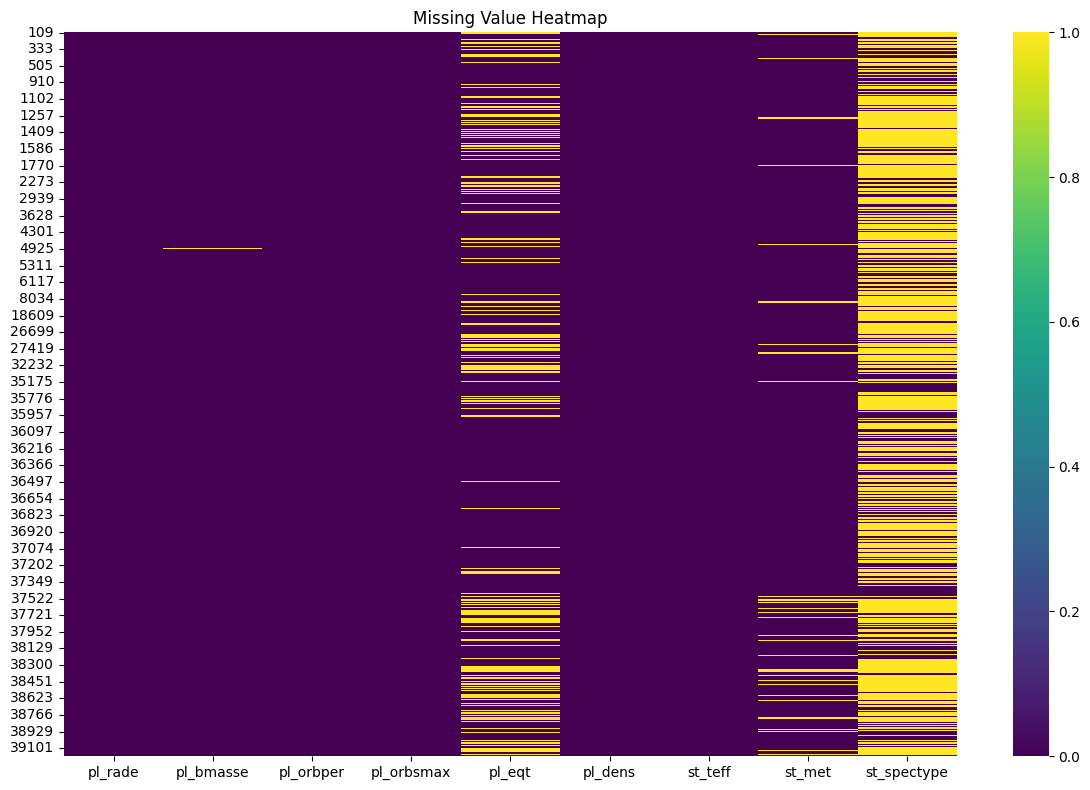

In [193]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=True,cmap = 'viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

In [194]:
planetary_cols = [
    'pl_rade', 'pl_bmasse', 'pl_orbper',
    'pl_orbsmax', 'pl_eqt', 'pl_dens','st_met'
]

star_temp_col = ['st_teff']
categorical_cols = ['st_spectype']

In [195]:
from sklearn.impute import SimpleImputer

planet_imputer = SimpleImputer(strategy='median')
df[planetary_cols] = planet_imputer.fit_transform(df[planetary_cols])

In [196]:
star_imputer = SimpleImputer(strategy='median')
df[star_temp_col] = star_imputer.fit_transform(df[star_temp_col])

In [197]:
df['st_spectype'].fillna(df['st_spectype'].mode()[0], inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_25376\351294900.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['st_spectype'].fillna(df['st_spectype'].mode()[0], inplace=True)


In [198]:
df.isnull().sum()

pl_rade        0
pl_bmasse      0
pl_orbper      0
pl_orbsmax     0
pl_eqt         0
pl_dens        0
st_teff        0
st_met         0
st_spectype    0
dtype: int64

### Handling Missing Values

In [199]:
from scipy import stats
import numpy as np

num_cols = df.select_dtypes(include=['float64', 'int64']).columns

z_scores = np.abs(stats.zscore(df[num_cols]))

df = df[(z_scores < 3).all(axis=1)]

In [200]:
cols = ['pl_rade', 'pl_bmasse', 'pl_orbper',
    'pl_orbsmax', 'pl_eqt', 'pl_dens','st_met','st_teff']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [201]:
# Negative radius
df = df[df['pl_rade'] > 0]

# Temperature must be > 0 Kelvin
df = df[df['pl_eqt'] > 0]

# Planet radius (Earth units)
df = df[df['pl_rade'] < 20]

# Star temperature
df = df[(df['st_teff'] > 2000) & (df['st_teff'] < 10000)]

# Orbital distance
df = df[df['pl_orbsmax'] < 50]

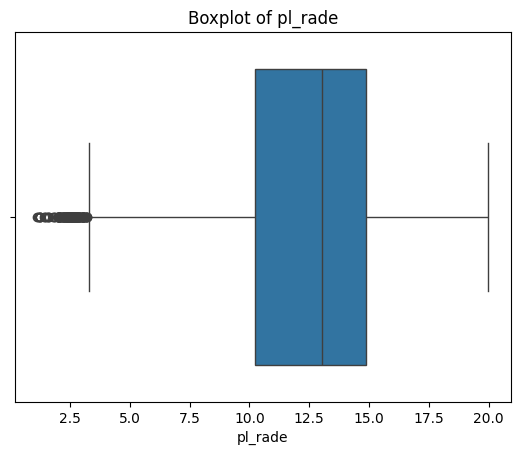

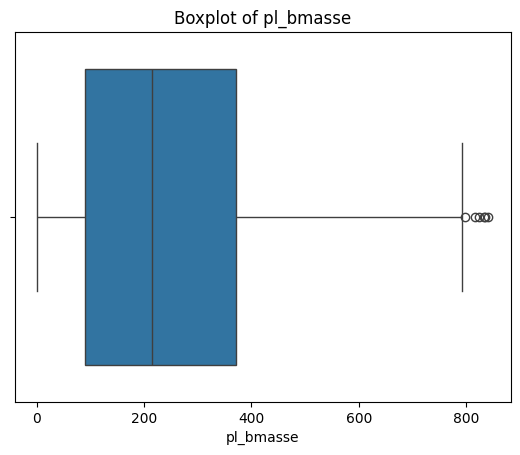

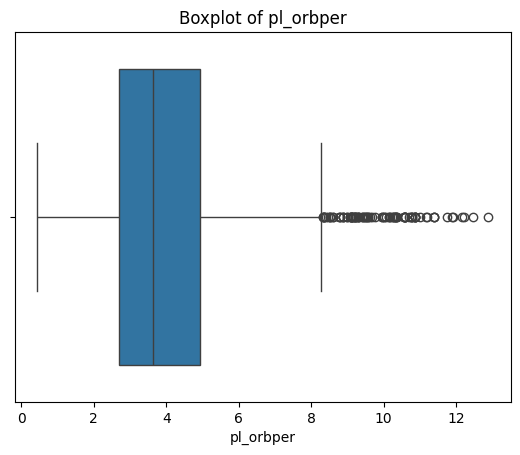

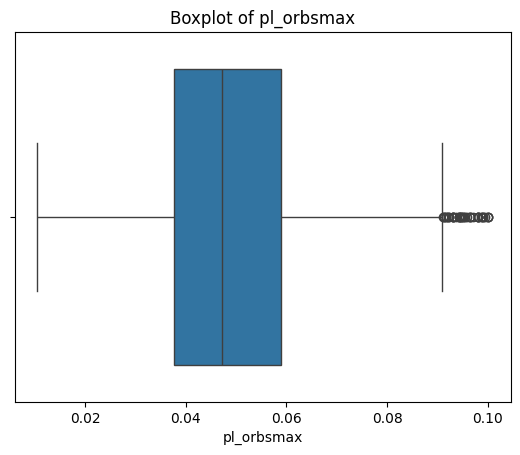

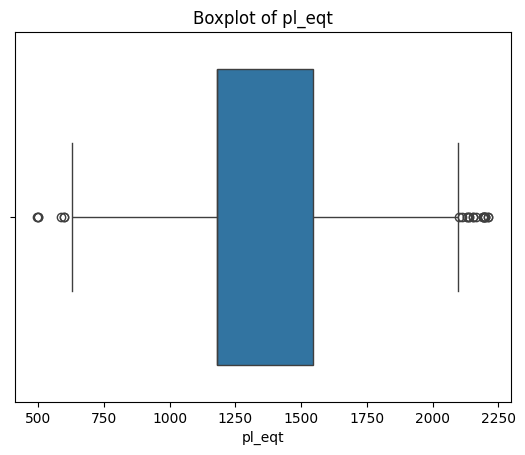

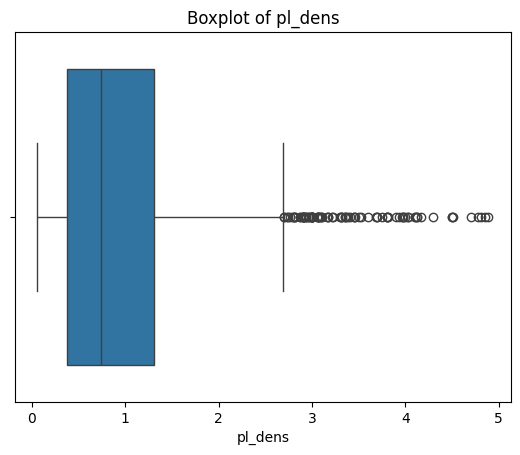

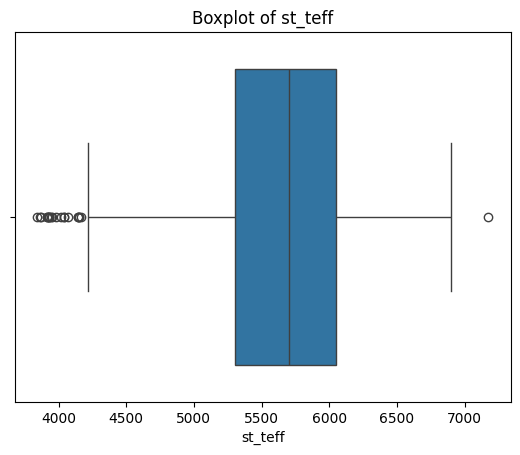

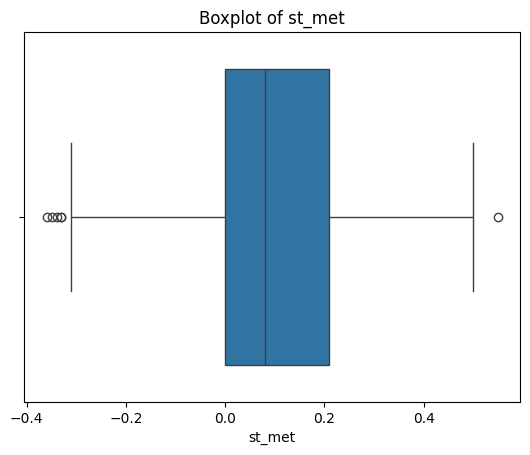

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [203]:
df = df[(df['pl_eqt'] > 100) & (df['pl_eqt'] < 2500)]

In [204]:
df['pl_bmasse'] = df['pl_bmasse'].clip(upper=800)

In [205]:
df.describe()

,pl_rade,pl_bmasse,pl_orbper,pl_orbsmax,pl_eqt,pl_dens,st_teff,st_met
count,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000
mean,11.808370,258.880959,4.177342,0.049702,1317.191934,1.046545,5634.419798,0.091425
std,4.667281,207.743562,2.370499,0.018282,335.409567,0.936503,587.128379,0.168200
min,1.137000,0.770000,0.446578,0.010550,497.700000,0.059000,3844.000000,-0.360000
25%,10.217004,89.355115,2.687938,0.037650,1180.000000,0.380000,5302.000000,0.000000
50%,13.047254,213.573000,3.648096,0.047300,1182.000000,0.740000,5700.000000,0.080000
75%,14.857567,371.693618,4.941110,0.059000,1547.000000,1.305000,6050.000000,0.210000
max,19.985613,800.000000,12.885779,0.100100,2212.000000,4.890000,7175.000000,0.549000


In [206]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['pl_eqt', 'pl_rade', 'pl_orbsmax']] = scaler.fit_transform(
    df[['pl_eqt', 'pl_rade', 'pl_orbsmax']]
)

In [207]:
def temp_score(T):
    # Ideal ~288K
    return np.maximum(0, 1 - np.abs(T - 288) / 288)

def radius_score(R):
    # Ideal ~1 Earth radius
    return np.maximum(0, 1 - np.abs(R - 1))

def distance_score(D):
    # Ideal ~1 AU
    return np.maximum(0, 1 - np.abs(D - 1))

def star_score(T_star):
    # Sun-like ~5778K
    return np.maximum(0, 1 - np.abs(T_star - 5778) / 5778)

In [208]:

def stellar_index(row):
    T = row['st_teff']
    
    # Temperature similarity to Sun
    temp_factor = max(0, 1 - abs(T - 5778) / 5778)
    
    # Stability factor (moderate stars better)
    stability_factor = 1 if 4000 < T < 7000 else 0.5
    
    return 0.7 * temp_factor + 0.3 * stability_factor

In [209]:
# Apply stellar index
df['stellar_index'] = df.apply(stellar_index, axis=1)

In [210]:
def orbital_stability(row):
    P = row['pl_orbper']     # in days
    D = row['pl_orbsmax']    # in AU
    
    # Convert period to years for Kepler relation
    P_years = P / 365
    
    # Kepler’s law: P^2 ≈ D^3 → P ≈ D^(3/2)
    expected = D ** 1.5
    
    return max(0, 1 - abs(P_years - expected))

In [211]:
# Apply orbital stability
df['orbital_stability'] = df.apply(orbital_stability, axis=1)

In [212]:
def habitability_score(row):
    t = temp_score(row['pl_eqt'])
    r = radius_score(row['pl_rade'])
    d = distance_score(row['pl_orbsmax'])
    s = star_score(row['st_teff'])
    
    # Weighted combination
    return (0.4 * t + 0.2 * r + 0.2 * d + 0.2 * s)

In [213]:
df.shape

(1091, 11)

In [214]:
# Apply habitability score
df['habitability_score'] = df.apply(habitability_score, axis=1)

# Ensure values are within range
df['habitability_score'] = df['habitability_score'].clip(0, 1)

In [215]:
df['st_spectype'] = df['st_spectype'].str[0]

In [216]:
print(df['st_spectype'].unique())

['G' 'F' 'K' 'M']


In [217]:
df = pd.get_dummies(df, columns=['st_spectype'])

In [218]:
df.shape

(1091, 15)

In [219]:
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [220]:
# Binary Classification
df['habitable'] = df['habitability_score'].apply(lambda x: 1 if x > 0.6 else 0)

In [221]:
# Multi-Class (optional)
def classify(score):
    if score < 0.3:
        return 0
    elif score < 0.7:
        return 1
    else:
        return 2

In [222]:
df['habitable_class'] = df['habitability_score'].apply(classify)

In [223]:
print(df[['habitability_score', 'stellar_index', 'orbital_stability']].head())

     habitability_score  stellar_index  orbital_stability
109           -3.061972      -0.107266           1.387584
121           -3.092240      -0.142380           1.395065
265            0.261899       0.674023           1.143329
266            0.016531       0.674023           1.125490
269            0.460510      -0.089709           1.070096


In [224]:
def habitability_score(row):
    t = temp_score(row['pl_eqt'])
    r = radius_score(row['pl_rade'])
    d = distance_score(row['pl_orbsmax'])
    s = star_score(row['st_teff'])

    # weighted average (temperature most important)
    return (0.4*t + 0.2*r + 0.2*d + 0.2*s)

df['habitability_score'] = df.apply(habitability_score, axis=1)

In [225]:
#binary classification: habitable if score > 0.5
df['habitable'] = df['habitability_score'].apply(lambda x: 1 if x > 0.6 else 0)

In [226]:
#multiclass classification: 0 = non-habitable, 1 = potentially habitable, 2 = highly habitable
def classify(x):
    if x < 0.3:
        return 0
    elif x < 0.7:
        return 1
    else:
        return 2

df['habitable_class'] = df['habitability_score'].apply(classify)

In [227]:
df.to_csv("C:\\Users\\hp\\Desktop\\project_intern\\New folder\\B13-ExoHabitAI\\data\\processed\\preprocessed2.csv", index=False)

In [228]:
df.shape

(1091, 17)